# making more wont stop (Edition 3)

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8] 

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
block_size = 3

def build_database(words):
    X, Y = [], []

    for w in words:
        context = [0] *block_size

        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_database(words[:n1])
Xdev, Yval = build_database(words[n1:n2])
Xte, Yte = build_database(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [22]:
n_embd = 10
n_hidden = 200

g = torch.Generator()
C = torch.randn((vocab_size, n_embd),             generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) / (n_embd * block_size)**0.5
b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn((vocab_size),                    generator=g) * 0

bngain = torch.randn((1, n_hidden))
bnbias = torch.randn((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad=True

12297


tensor(-0.0040) tensor(0.9967)
tensor(0.0026) tensor(0.9990)


(array([4.40845474e-05, 1.32253642e-04, 1.76338190e-04, 1.54295916e-04,
        2.42465011e-04, 3.08591832e-04, 5.06972295e-04, 7.71479580e-04,
        1.43274779e-03, 2.40260783e-03, 4.05577836e-03, 6.30409028e-03,
        1.02055727e-02, 1.58924793e-02, 2.56351643e-02, 3.78465839e-02,
        5.87647017e-02, 8.68686007e-02, 1.24031874e-01, 1.70430860e-01,
        2.31465916e-01, 2.89966111e-01, 3.59222935e-01, 4.02712341e-01,
        4.32755960e-01, 4.30066802e-01, 3.90390710e-01, 3.41214397e-01,
        2.73809124e-01, 2.11076813e-01, 1.55221691e-01, 1.15170880e-01,
        7.79635221e-02, 5.40917397e-02, 3.55321452e-02, 2.27696687e-02,
        1.52532534e-02, 9.39000860e-03, 4.71704657e-03, 3.74718653e-03,
        2.29239646e-03, 1.41070552e-03, 7.71479580e-04, 5.51056843e-04,
        2.42465011e-04, 1.54295916e-04, 1.54295916e-04, 6.61268211e-05,
        4.40845474e-05, 2.20422737e-05]),
 array([-5.63928795, -5.4124511 , -5.18561424, -4.95877739, -4.73194054,
        -4.50510368, 

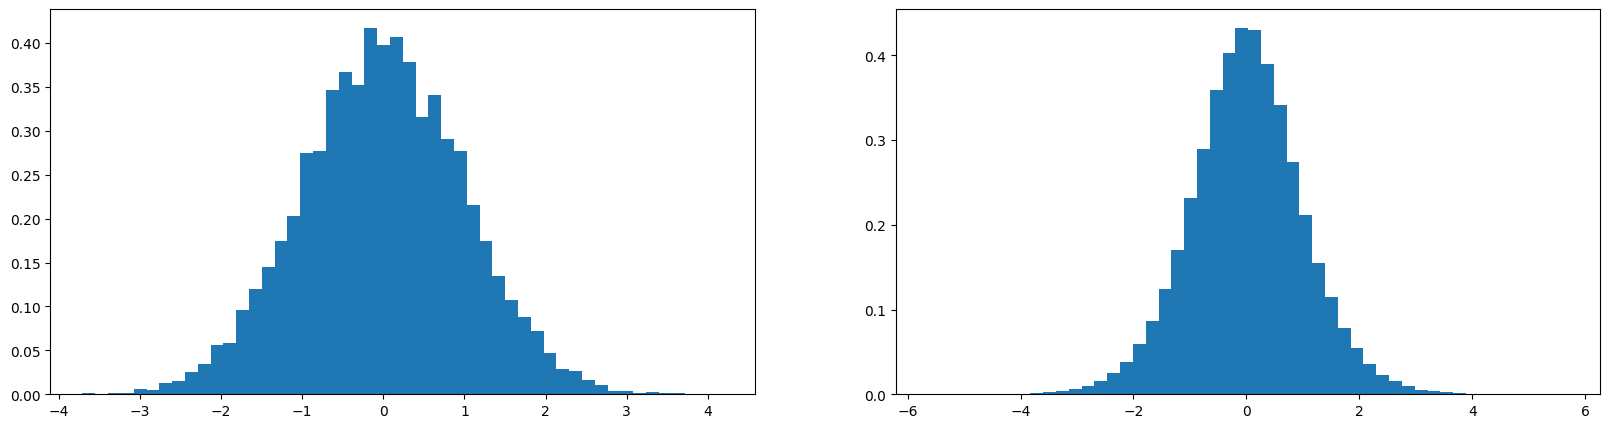

In [23]:
x = torch.randn(1000, 10)
w = torch.randn(10, 200) / 10**0.5
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())

plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True)
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True)

In [24]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)
    
    hpreact = embcat @ W1 + b1
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias

    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data -= lr * p.grad
    
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item(): .4f}')
    lossi.append(loss.log10().item())
    # break

      0/ 200000:  3.3003
  10000/ 200000:  2.4130
  20000/ 200000:  2.8239
  30000/ 200000:  2.1574
  40000/ 200000:  2.1687
  50000/ 200000:  2.1669
  60000/ 200000:  2.2518
  70000/ 200000:  1.6036
  80000/ 200000:  1.9435
  90000/ 200000:  2.3084
 100000/ 200000:  2.3426
 110000/ 200000:  2.1159
 120000/ 200000:  2.4331
 130000/ 200000:  1.7905
 140000/ 200000:  1.8486
 150000/ 200000:  2.1314
 160000/ 200000:  2.3583
 170000/ 200000:  2.1157
 180000/ 200000:  1.8386
 190000/ 200000:  1.9370


(array([535., 174., 145., 119., 109.,  97.,  82.,  82.,  72.,  62.,  62.,
         77.,  66.,  54.,  65.,  50.,  67.,  61.,  76.,  67.,  83.,  89.,
        113., 184., 716., 610., 184., 103.,  92.,  86.,  71.,  61.,  57.,
         59.,  52.,  52.,  51.,  58.,  60.,  72.,  69.,  78.,  55.,  84.,
         80.,  93., 106., 131., 202., 527.]),
 array([-9.99997735e-01, -9.59997785e-01, -9.19997835e-01, -8.79997885e-01,
        -8.39997935e-01, -7.99997985e-01, -7.59998035e-01, -7.19998085e-01,
        -6.79998136e-01, -6.39998186e-01, -5.99998236e-01, -5.59998286e-01,
        -5.19998336e-01, -4.79998386e-01, -4.39998436e-01, -3.99998486e-01,
        -3.59998536e-01, -3.19998586e-01, -2.79998636e-01, -2.39998686e-01,
        -1.99998736e-01, -1.59998786e-01, -1.19998837e-01, -7.99988866e-02,
        -3.99989367e-02,  1.01327896e-06,  4.00009632e-02,  8.00009131e-02,
         1.20000863e-01,  1.60000813e-01,  2.00000763e-01,  2.40000713e-01,
         2.80000663e-01,  3.20000613e-01,  3.60000

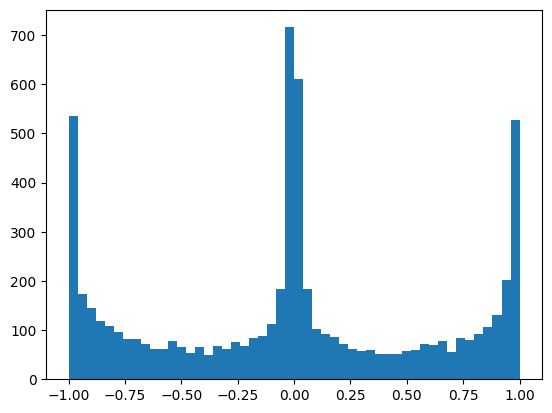

In [26]:
plt.hist(h.view(-1).tolist(), 50)

(array([2.000e+00, 1.000e+00, 1.000e+00, 7.000e+00, 2.000e+00, 4.000e+00,
        9.000e+00, 1.100e+01, 1.800e+01, 3.400e+01, 2.300e+01, 4.200e+01,
        5.300e+01, 7.600e+01, 8.100e+01, 1.010e+02, 1.380e+02, 1.570e+02,
        2.230e+02, 2.690e+02, 3.040e+02, 3.680e+02, 7.560e+02, 1.801e+03,
        3.440e+02, 3.180e+02, 2.380e+02, 2.180e+02, 1.600e+02, 1.520e+02,
        1.120e+02, 9.800e+01, 8.300e+01, 4.800e+01, 3.900e+01, 2.700e+01,
        2.800e+01, 1.300e+01, 1.100e+01, 1.300e+01, 5.000e+00, 3.000e+00,
        1.000e+00, 2.000e+00, 4.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00]),
 array([-6.84532642, -6.54897184, -6.25261726, -5.95626268, -5.6599081 ,
        -5.36355352, -5.06719894, -4.77084436, -4.47448978, -4.1781352 ,
        -3.88178062, -3.58542604, -3.28907146, -2.99271688, -2.6963623 ,
        -2.40000772, -2.10365314, -1.80729856, -1.51094398, -1.21458941,
        -0.91823483, -0.62188025, -0.32552567, -0.02917109,  0.26718349,
         0.

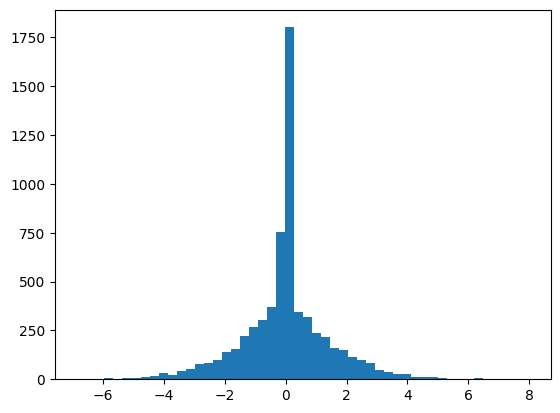

In [27]:
plt.hist(hpreact.view(-1).tolist(), 50)

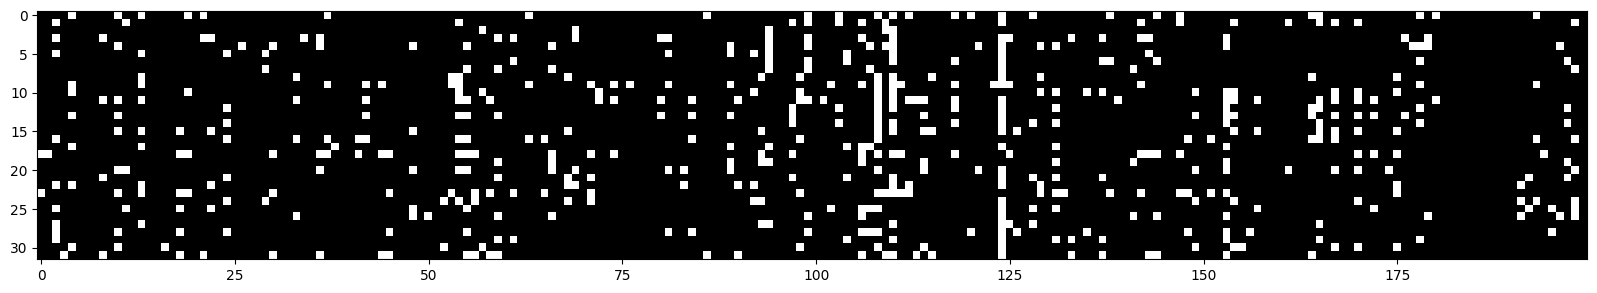

In [28]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

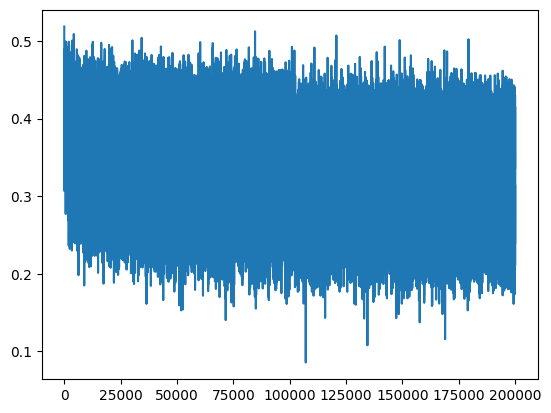

In [29]:
plt.plot(lossi)

In [30]:
with torch.no_grad():
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 # + b1
  
  bnmean = hpreact.mean(0, keepdim=True)
  bnstd = hpreact.std(0, keepdim=True)

In [31]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Yval),
        'test': (Xte, Yte),
    }[split]

    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')
split_loss('test')

train 2.0963332653045654
val 2.1263301372528076
test 2.1232383251190186


In [34]:
g = torch.Generator()

for _ in range(20):

    out = []
    context = [0] * block_size

    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)

        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)

        if ix == 0:
            break
    
    print(''.join(itos[i] for i in out))

criouuicrhbvtx.
cxvhwx.
cxauznvtddxmvpz.
cqhhnndzxquhuvkqneulnguogueauuuuuucrhby.
uuuucuuuuuuuxuucoiwgdvxboruynq.
cwex.
cceauuuuukemlprgekqeruauuuuuuuuhuuuuuuuuuucrmlkz.
icrhbc.
cweiaayuuiczekzekoiufex.
cxofaguxuvnvtd.
cxekaiuuiauuhorneuznhbhnvtwudnkzmndpemlprgxy.
cxvkofaghx.
cvekaaicdekaeuuuuuuuuucrhiouuijcy.
icgxx.
ceweauhhqno.
cvaxufekaaauuuuzpenguunllxguouuiceiczns.
cdvxmnptwgdy.
cwei.
zcvnvlkgeeufetgwkeauiiddvxmotgx.
crvpkaaaeucyuuicvaforgxg.
